
# Implementacion del modelo de Heston

Complemento practico a la Seccion 5 del TFM (Heston: fundamentos matematicos e implementacion numerica).

Se sigue la siguente estructura:
1. Especificacion del modelo (Seccion 5.1)
2. Funcion caracteristica, formulacion estable de Albrecher et al. (2007) (Seccion 5.3)
3. Pricing semi-analitico via inversion (Gil-Pelaez) (Seccion 5.4, via semi-analitica)
4. Simulacion Monte Carlo con full truncation (Seccion 5.4, via Monte Carlo)
5. Validacion cruzada semi-analitico vs Monte Carlo
6. Sonrisa de volatilidad: Heston vs Black-Scholes vs mercado
7. Calibracion aproximada de los 5 parametros (Seccion 5.5)

**Nota de desarrollo:** durante la implementación se contrastó la formulación de la función característica y el esquema de Monte Carlo con

- Crisóstomo (2015)
- El notebook *1.4 SDE - Heston model* del repositorio [cantaro86/Financial-Models-Numerical-Methods](https://github.com/cantaro86/Financial-Models-Numerical-Methods/blob/master/1.4%20SDE%20-%20Heston%20model.ipynb)

El segundo sigue el mismo planteamiento (Gil-Pelaez para el pricing semi-analítico, Euler-Maruyama para la simulación) aunque con distinta implementación para la no negatividad de $v_t$ (variables logarítmicas frente al full truncation de Lord et al., 2010, usado aquí). Ese notebook atribuye la forma estable de $\varphi$ a Schoutens, Simons & Tistaert (2004), *A perfect calibration! Now what?*, Wilmott Magazine, referencia anterior y afín a la de Albrecher et al. (2007) usada en el TFM.

**Referencias teóricas y de implementación**

- Heston, S. (1993), *A Closed-Form Solution for Options with Stochastic Volatility...*, Review of Financial Studies, 6(2), 327-343. Especificación del modelo.
- Schoutens, W., Simons, E. & Tistaert, J. (2004), *A Perfect Calibration! Now What?*, Wilmott Magazine, y Albrecher, H., Mayer, P., Schoutens, W. & Tistaert, J. (2007), *The Little Heston Trap*, Wilmott Magazine, No. 1, 83-92. Formulación estable de la función característica. La referencia a Schoutens et al. (2004) se comparte con la siguiente referencia.
- Repositorio [cantaro86/Financial-Models-Numerical-Methods](https://github.com/cantaro86/Financial-Models-Numerical-Methods/blob/master/1.4%20SDE%20-%20Heston%20model.ipynb), usado como punto de contraste durante el desarrollo.
- Gil-Pelaez, J. (1951), *Note on the Inversion Theorem*, Biometrika, 38(3-4), 481-482. Sobre inversión de la función característica para el pricing semi-analítico.
- Higham, D.J. (2001), *An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations*, SIAM Review, 43(3). Esquema base de Euler-Maruyama (ya usado en el Anexo 2).

**Nota sobre Oosterlee & Grzelak (2019):** aunque es la referencia numerica de cabecera para Heston en el TFM, esta implementacion en concreto *no* sigue su metodo. En ese libro se resuelven la valoración casi enteramente con el **metodo COS** (Fang & Oosterlee, 2008), mientras que aqui se usa la cuadratura directa de Gil-Pelaez (mas clasica y sencilla para iniciarse, en la linea de Heston/Gatheral).

In [1]:

import numpy as np
from scipy import integrate, optimize, stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['figure.figsize'] = (8, 4.5)
# Estandarizacion del tamaño y estilo de las figuras
plt.rcParams['figure.figsize'] = (8, 4.5)  
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
})




## 1. Especificacion del modelo 
Motivación/contexto: Empezamos con una comparación clara con el modelo de Black Scholes. En Black-Scholes bastaba con la determinación de una unica constante  $\sigma$ para determinar el modelo (la cual se podía estimar de forma directa a partir de la volatilidad historica de la serie temporal de precios). Segun vimos en teoría en el modelo de Heston la varianza ya no es una constante sino un proceso con su propia dinamica estocástica. Esto introduce cuatro parámetros nuevos ($\kappa,\theta,\xi,\rho$) con la problemática que no se puede calcular algunos de ellos directamente de la serie de precios. En la seccion 7 de este jupyter se mostrará una metodología para el calculo de estos parámetros. El resumen queda en que será necesario un proceso de calibración contra los precios de las opciones correspondientes ya observadas en el mercado.

En esta seccion se usarán unos parametros de referencia los cuales nos sirven para empezezar a ejemplificar como desarrollar el modelo.

----
$$
dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW_t^{S}, \qquad
dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW_t^{v}, \qquad
\mathrm{Corr}(dW_t^S, dW_t^v) = \rho.
$$

Parametros: $v_0$ (varianza inicial), $\kappa$ (velocidad de reversion), $\theta$ (varianza de largo plazo), $\xi$ (vol de la vol), $\rho$ (correlacion). Ya bajo la medida neutral al riesgo $Q$, con drift $r$.


In [2]:
# Parametros de referencia usados como punto de partida
v0    = 0.04   # varianza inicial 
kappa = 2.0    # velocidad de reversion
theta = 0.04   # varianza de largo plazo 
xi    = 0.30   # vol de la vol
rho   = -0.65  # correlacion 

S0 = 100.0   # precio incial
r  = 0.03    # tasa libre de riesgo

# Necesario cumplimiento de la condicion de Feller: 2*kappa*theta >= xi^2
feller = 2 * kappa * theta
print(f"2*kappa*theta = {feller:.4f}   vs   xi^2 = {xi**2:.4f}")
print("condicion de Feller satisfecha:" , feller >= xi**2)


2*kappa*theta = 0.1600   vs   xi^2 = 0.0900
condicion de Feller satisfecha: True



## 2. Funcion caracteristica 
Ya vimos cómo el precio de la opcion europea mediante Black Scholes se escribe como una formula analitica cerrada en terminos de:
- La distribucion normal ($N(d_1), N(d_2)$)

En Heston no esiste una forma similar a esta, no existiendo una forma cerrada simple. En el texto del trabajo vimos como sí que podemos obtener una funcion caracteristica con una forma tipo cerrada:

- Funcion caracteristica $\varphi(u)$: la transformada de Fourier de la densidad de $\ln S_T$

La idea para esta seccion será ver si podemos calcular con código la forma de  $\varphi(u)$ de forma cerrada y cómo se puede recuperar el precio de la opcion invirtiendo esa transformada.

---
Merece la pena hacer un inciso sobre un problema de estabilidad  numerica típico a la hora de programar la función característica:

$$
\varphi(u) = \exp\big(C(\tau,u) + D(\tau,u)v_0 + iu\ln S_0\big), \qquad \tau = T,
$$

$$
D(\tau,u) = \frac{a-d}{\xi^2}\cdot\frac{1-e^{-d\tau}}{1-ge^{-d\tau}}, \qquad
C(\tau,u) = iur\tau + \frac{\kappa\theta}{\xi^2}\left[(a-d)\tau - 2\ln\!\left(\frac{1-ge^{-d\tau}}{1-g}\right)\right],
$$

con $a=\kappa-\rho\xi iu$, $d=\sqrt{a^2+\xi^2(u^2+iu)}$, $g=(a-d)/(a+d)$.

Esta es la formulacion "little trap" de Albrecher et al. (2007). Es simplemente una solucion alternativa que evita problemas de estabilidad debidos a que el logaritmo complejo, a diferencia del logaritmo real, no tiene un unico valor y el ordenador tiene que elegir uno solo para poder devolver un numero. 

Esto hace que la integral numerica se vuelva incorrecta en ciertos contextos computacionales, sin que el codigo de ningun error visible. La clave esta en la eleccion de $g$: escribir $g=(a-d)/(a+d)$, como se ha hecho arriba, en vez de su inverso, es lo que evita ese salto para los rangos de $u$ y $\tau$ relevantes en pricing.

In [3]:

def heston_char_func(u, S0, v0, kappa, theta, xi, rho, r, tau):
    # Funcion caracteristica de x_T = ln(S_T) bajo Q, formulacion estable
    u = np.asarray(u, dtype=complex) #Permitimos al array ser complejo

    #Calculamos a,d,g
    a = kappa-rho*xi*1j*u
    d = np.sqrt(a**2+xi**2*(u**2+1j * u))
    g = (a-d)/(a+d)
    exp_dt = np.exp(-d * tau)

    # D y C de la solucion de la Riccati
    D = (a-d) / xi**2 * (1-exp_dt) / (1 - g*exp_dt)

    C = (1j*u*r*tau + kappa*theta / xi**2 * ((a-d) * tau-2 * np.log((1-g * exp_dt) / (1-g))))

    x0 = np.log(S0)
    return np.exp(C + D * v0 + 1j * u * x0)


### 2.1 Verificacion cruzada con Monte Carlo

Cualquier error de signo o de rama compleja en la formula de $\varphi(u)$ pasaria desapercibido durante el resto del notebook, y contaminaria en cascada tanto el pricing semi-analitico como la comparacion frente a Monte Carlo. 

Veamos que $\varphi(u)$ funciona antes de hacer los códigos de pricing. La comprobación en este caso consiste en ver lo que se obtendria simulando trayectorias y calculando $\mathbb E[e^{iu\ln S_T}]$ directamente por Monte Carlo.


In [4]:

def simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r, T, n_steps, n_paths, seed=None):
    # Simulacion Euler-Maruyamas.
    # Devuelve S_T y v_T (arrays de tamano n_paths).
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    for _ in range(n_steps):
        Z1 = rng.standard_normal(n_paths)
        Z2 = rng.standard_normal(n_paths)
        dW_S = np.sqrt(dt) * Z1
        dW_v = rho * dW_S + np.sqrt(1 - rho**2) * np.sqrt(dt) * Z2

        v_pos = np.maximum(v, 0.0)   # full truncation: v_t^+ = max(v_t, 0)

        S = S * np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos) * dW_S)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos) * dW_v

    return S, v


# Comprobamos phi(u) VS MC
# Parametros para simulacion Monte Carlo 
T = 1.0
n_steps = 200
n_paths = 200_000
seed    = 42

S_T, _ = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r, T, n_steps, n_paths, seed)
x_T = np.log(S_T)

for u_test in [0.5, 1.0, 2.0]:
    phi_formula    = heston_char_func(u_test, S0, v0, kappa, theta, xi, rho, r, T)
    phi_montecarlo = np.mean(np.exp(1j * u_test * x_T))

    print(f"u={u_test}:  formula={phi_formula:.4f}   monte carlo={phi_montecarlo:.4f}")

u=0.5:  formula=-0.6685+0.7366j   monte carlo=-0.6686+0.7365j
u=1.0:  formula=-0.0938-0.9747j   monte carlo=-0.0935-0.9746j
u=2.0:  formula=-0.9048+0.1691j   monte carlo=-0.9046+0.1685j



## 3. Pricing semi-analitico via inversion (Seccion 5.4, via semi-analitica)

Con $\varphi(u)$ ya comprobada, toca dar el paso que motivaba toda la seccion anterior: pasar de la funcion caracteristica al precio de la opcion. La idea, debida a Gil-Pelaez (1951), es que la funcion caracteristica determina por completo la distribucion, y en particular permite recuperar directamente las dos probabilidades $P_1,P_2$ que aparecen en la formula de Heston. Se podría considerer el equivalente, en este modelo, a los $N(d_1)$ y $N(d_2)$ de Black-Scholes. No hace falta invertir la transformada para obtener la densidad completa: basta con una integral numerica por cada probabilidad.

Con $\varphi(u)$ ya validada, el precio de una call europea se escribe (utilizamos la referencia dada por Crisostomo, 2015 junto con sus implementaciones adaptadas):

$$
C = S_0 P_1 - Ke^{-rT}P_2,
$$

$$
P_2 = \frac12 + \frac1\pi\int_0^\infty \mathrm{Re}\left[\underbrace{\frac{e^{-iu\ln K}\varphi(u)}{iu}}_{\text{Integrando 2}}\right]du, \qquad
P_1 = \frac12 + \frac1\pi\int_0^\infty \mathrm{Re}\left[\underbrace{\frac{e^{-iu\ln K}\varphi(u-i)}{iu\,\varphi(-i)}}_{\text{Integrando 1}}\right]du.
$$

Cada integral se calcula numericamente (mediante cuadratura estandar de scipy): la parte marcada como "el integrando" es exactamente lo que programan.

In [ ]:
def integrand_P2(u, phi, K):
    val = np.exp(-1j*u*np.log(K))*phi(u) / (1j*u)
    return val.real

def integrand_P1(u, phi, K):
    val = np.exp(-1j*u*np.log(K))*phi(u-1j) / (1j*u*phi(-1j))
    return val.real


def heston_call_price(S0, K, T, kappa, theta, xi, rho, v0, r):
    # Precio de una call europea via inversion de la funcion caracteristica.
    # Marco de Crisostomo (2015), original en Matlab.
    phi = lambda u: heston_char_func(u, S0, v0, kappa, theta, xi, rho, r, T)

    #Integracion
    int_P2, _ = integrate.quad(integrand_P2, 1e-8, 100.0, args=(phi, K), limit=200)
    int_P1, _ = integrate.quad(integrand_P1, 1e-8, 100.0, args=(phi, K), limit=200)

    P2 = 0.5 + int_P2 / np.pi
    P1 = 0.5 + int_P1 / np.pi

    return S0 * P1 - K * np.exp(-r * T) * P2

In [ ]:
# Al igual que Crisostomo (2015) realizamos validacion con el benchmark de Kahl & Jackel (2005)
# Valor publicado: C0 = 0.0495. 

# Parametros de referencia benchmark
v0_kj    = 0.16   # varianza inicial
kappa_kj = 1.0    # velocidad de reversion
theta_kj = 0.16   # varianza de largo plazo
xi_kj    = 2.0    # vol de la vol
rho_kj   = -0.8   # correlacion

S0_kj    = 1.0    # precio inicial
r_kj     = 0.0    # tasa libre de riesgo

# ¿ Necesario cumplimiento de la condicion de Feller: 2*kappa*theta >= xi^2 ?
feller_kj = 2 * kappa_kj * theta_kj
print(f"2*kappa*theta = {feller_kj:.4f}   vs   xi^2 = {xi_kj**2:.4f}")
print("condicion de Feller satisfecha:", feller_kj >= xi_kj**2)

# Constantes para el test
K_kj     = 2.0    # strike
T_kj     = 10.0   # vencimiento

precio_benchmark = heston_call_price(S0_kj, K_kj, T_kj, kappa_kj, theta_kj, xi_kj, rho_kj, v0_kj, r_kj)
print(f"Precio obtenido:  {precio_benchmark:.3}")
print(f"Benchmark:  0.0495 ")

2*kappa*theta = 0.3200   vs   xi^2 = 4.0000
condicion de Feller satisfecha: False
Precio obtenido:  0.0495
Benchmark:  0.0495 


**Sobre la violación de la condición de Feller en este benchmark**

La condición de Feller, $2\kappa\theta\ge\xi^2$ (Feller, 1951), garantiza que el proceso de varianza $v_t$ nunca alcanza cero. En el escenario de Kahl & Jäckel (2005) se viola deliberadamente ($2\kappa\theta=0.32$ frente a $\xi^2=4.0$): es precisamente un ejemplo (utilizado por Kahl & Jäckel (2005)) que se usa para forzar la discontinuidad del logaritmo complejo conocida como *Heston trap*. No es, por tanto, un error de calibración de los parámetros, sino el objetivo mismo del test.

## 4. Pricing via Monte Carlo (Seccion 5.4, via Monte Carlo)

Ya visto en otras secciones, se trata del promedio del pago descontado. Aqui se aplica ese mismo principio como via alternativa al pricing semi-analitico. Sirve como forma independiente de llegar al mismo precio.

Mas alla de esta validacion, el interes real del Monte Carlo esta en su versatilidad: el metodo nunca dependerá de que exista una solucion cerrada, nos basta con la simulación de trayectorias y el promedio del pago descontado.

In [8]:
def heston_call_mc(S0, K, T, kappa, theta, xi, rho, v0, r, n_steps=200, n_paths=200_000, seed=None):
    S_T, _ = simulate_heston_paths(S0, v0, kappa, theta, xi, rho, r, T,
                                    n_steps=n_steps, n_paths=n_paths, seed=seed)
    payoff = np.maximum(S_T - K, 0.0)
    precio = np.exp(-r * T) * payoff.mean()
    return precio


# Contraste MC vs semi-analitico
precio_mc_kj = heston_call_mc(S0_kj, K_kj, T_kj, kappa_kj, theta_kj, xi_kj, rho_kj, v0_kj, r_kj, seed=43)
precio_semianalitico_kj = heston_call_price(S0_kj, K_kj, T_kj, kappa_kj, theta_kj, xi_kj, rho_kj, v0_kj, r_kj)

print(f"Precio (Monte Carlo):     {precio_mc_kj:.3f}")
print(f"Precio (semi-analitico):  {precio_semianalitico_kj:.3f}")
print(f"Valor publicado:          0.0495")

Precio (Monte Carlo):     0.052
Precio (semi-analitico):  0.050
Valor publicado:          0.0495


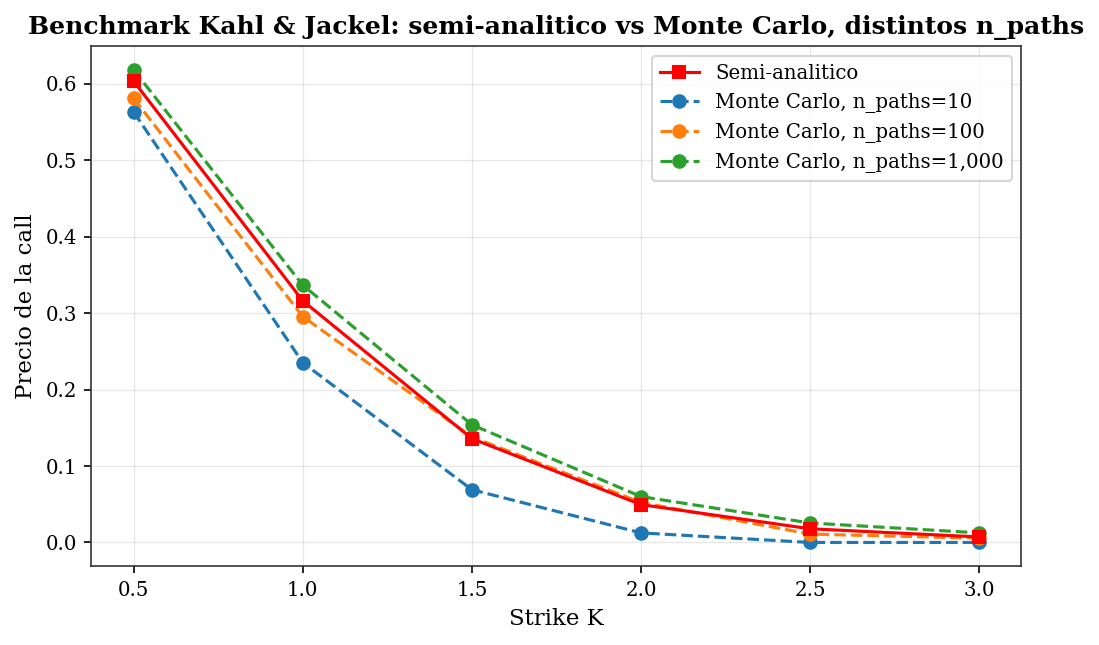

In [9]:
############# Comparación de los metodos a distintos strikes 
strikes_kj = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])   # de muy ITM a muy OTM. Partimos de S0_kj=1
n_paths_list = [10, 100, 1000]                 # tres sizes de simulacion, para ver la convergencia

precios_sa_kj = []
for K in strikes_kj:
    p_sa = heston_call_price(S0_kj, K, T_kj, kappa_kj, theta_kj, xi_kj, rho_kj, v0_kj, r_kj)
    precios_sa_kj.append(p_sa)
precios_sa_kj = np.array(precios_sa_kj)

resultados_mc = {}   # array de precios por cada n_paths
for n_paths in n_paths_list:
    precios = []
    for K in strikes_kj:
        p_mc = heston_call_mc(S0_kj, K, T_kj, kappa_kj, theta_kj, xi_kj, rho_kj, v0_kj, r_kj,
                               n_paths=n_paths, seed=3)
        precios.append(p_mc)
    resultados_mc[n_paths] = np.array(precios)

#########################
#########################
#########################F Representaciones
plt.plot(strikes_kj, precios_sa_kj, 'r-', marker='s', label='Semi-analitico', zorder=3)
for n_paths, precios in resultados_mc.items():
    plt.plot(strikes_kj, precios, 'o--', label=f'Monte Carlo, n_paths={n_paths:,}')

plt.xlabel('Strike K')
plt.ylabel('Precio de la call')
plt.grid(alpha=0.3)
plt.title('Benchmark Kahl & Jackel: semi-analitico vs Monte Carlo, distintos n_paths')
plt.legend()

## 5. Sonrisa de volatilidad: Heston vs Black-Scholes vs mercado

Volvemos a la motivación inicial del proyecto. El modelo de Heston surge como mejora orgánica al modelo de Black Scholes para capturar mejor la naturaleza no constante de la volatilidad. Esto se puede ver en la conocida sonrisa de volatilidad al invertir los precios de las opciones a volatilidad con Black Scholes.

En principio Heston, al modelar la varianza como un proceso estocastico propio con su reversion a la media, su volatilidad asociada a la vol y su correlacion con el precio debería tener los grados de libertad necesarios para generar una curva de volatilidad implicita con skewness. 

Se invierte cada precio de Heston (para distintos strikes) a su volatilidad implicita de Black-Scholes, y se compara con la linea plana que predice Black-Scholes con $\sigma$ constante. Primero se ilustra el resultado con una sonrisa "de mercado" sintetica, con la forma tipica de skew de equity. Despues, en la Seccion 5.1, se repite exactamente la misma comparacion pero descargando una cadena de opciones real sobre SPY (via `yfinance`), para comprobar si esa misma forma se sostiene tambien frente a datos de mercado reales, no solo frente a una curva construida a proposito para parecerse a Heston.

In [ ]:
from scipy.stats import norm
from scipy.optimize import brentq
import yfinance as yf
from datetime import datetime

def bs_call_price(S0, K, T, r, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def implied_vol(precio_mercado, S0, K, T, r):
    # Inversion numerica: buscamos la sigma que reproduce el precio observado
    objetivo = lambda sigma: bs_call_price(S0, K, T, r, sigma) - precio_mercado
    try:
        return brentq(objetivo, 1e-6, 5.0)
    except ValueError:
        return np.nan   # precio fuera del rango alcanzable por BS (arbitraje / bid-ask sucio)

In [ ]:
#Check de datos disponibles
print("Fecha/hora actual:", datetime.now())
print("Version yfinance:", yf.__version__)

tk = yf.Ticker("SPY")
print("Vencimientos disponibles:", tk.options[:5])

vencimiento = tk.options[2]
raw = tk.option_chain(vencimiento).calls
print("Vencimiento probado:", vencimiento)
print("Filas totales:", len(raw))
print(raw[["strike","bid","ask","lastPrice"]].describe())

[*********************100%***********************]  1 of 1 completed


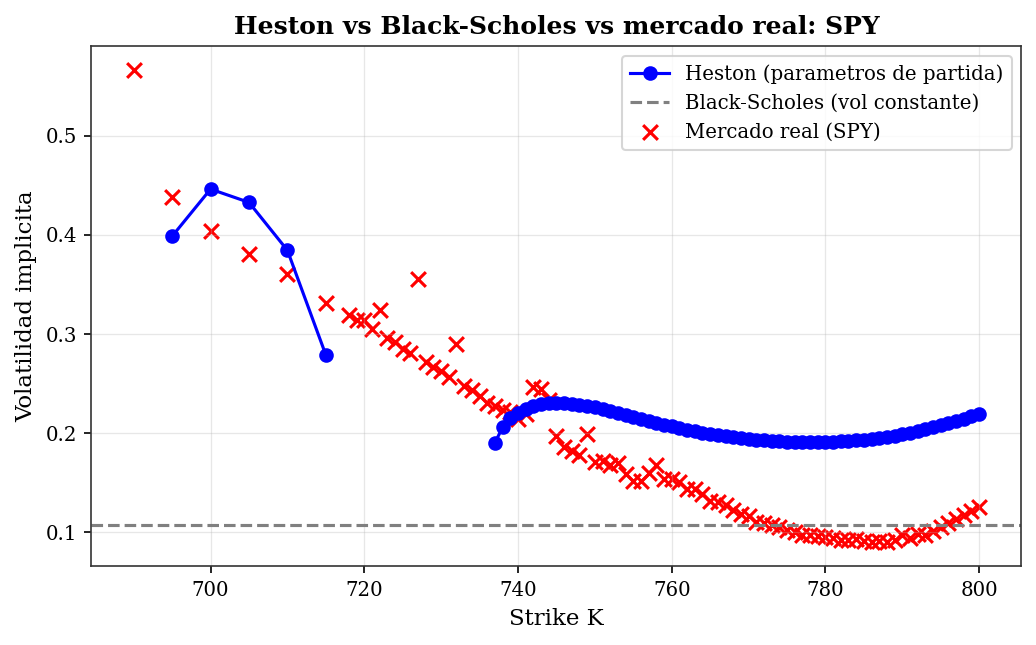

In [ ]:
# pip install yfinance
from datetime import datetime

#Descarga de precios 
S0_real = yf.download("SPY", period="1d")["Close"].iloc[-1].item()

#Descarga de datos sobre opciones
vencimiento = yf.Ticker("SPY").options[2]   # Vencimiento medio. Ni muy lejano ni el mas actual
T_real = (datetime.strptime(vencimiento, "%Y-%m-%d") - datetime.today()).days / 365
calls = yf.Ticker("SPY").option_chain(vencimiento).calls
calls = calls[(calls["bid"] > 0) & (calls["ask"] > 0)]
calls["mid"] = (calls["bid"] + calls["ask"]) / 2 #Entre cotizaciones. 

#Strike prices reales
strikes = calls["strike"].values
vols = np.array([implied_vol(p, S0_real, K, T_real, r) for p, K in zip(calls["mid"], strikes)])

vols_heston = []
for K in strikes:
    precio_heston = heston_call_price(S0_real, K, T_real, kappa, theta, xi, rho, v0, r)
    vols_heston.append(implied_vol(precio_heston, S0_real, K, T_real, r))
vols_heston = np.array(vols_heston)

# Black-Scholes: una sola sigma constante, tomada del strike real mas cercano al ATM
idx_atm = np.argmin(np.abs(strikes - S0_real))
sigma_bs_flat = vols[idx_atm]

##################################
##################################
################################## Representaciones
plt.plot(strikes, vols_heston, 'b-', marker='o', label='Heston (parametros de partida)')
plt.axhline(sigma_bs_flat, color='gray', linestyle='--', label='Black-Scholes (vol constante)')
plt.scatter(strikes, vols, color='red', marker='x', s=50, label='Mercado real (SPY)')
plt.xlabel('Strike K')
plt.ylabel('Volatilidad implicita')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Heston vs Black-Scholes vs mercado real: SPY')
#plt.savefig('heston_bs_mercado_spy.pdf', bbox_inches='tight', dpi=220)   # celda 15
plt.show()

## 7. Calibracion aproximada (Seccion 5.5)

En la seccion anterior vimos que Heston, con los parametros de partida, ya es capaz de generar una curva, no una linea plana como Black-Scholes. No obstante esa curva no tiene por que coincidir con la del mercado real: los parametros $(\kappa,\theta,\xi,\rho,v_0)$ se eligieron sin calibrar ningun dato a mercado. 

Esta seccion cierra ese hueco: se ajustan los 5 parametros minimizando la suma de errores de precio al cuadrado frente a los precios reales de la cadena de opciones de SPY descargada antes, via `scipy.optimize.least_squares` (optimizacion numerica estandar).

Parametro      Partida      Calibrado
v0             0.0400       0.0194
kappa          2.0000       1.2863
theta          0.0400       0.0001
xi             0.3000       0.3265
rho            -0.6500      -0.9990

Error cuadratico medio final (precios): 0.273108


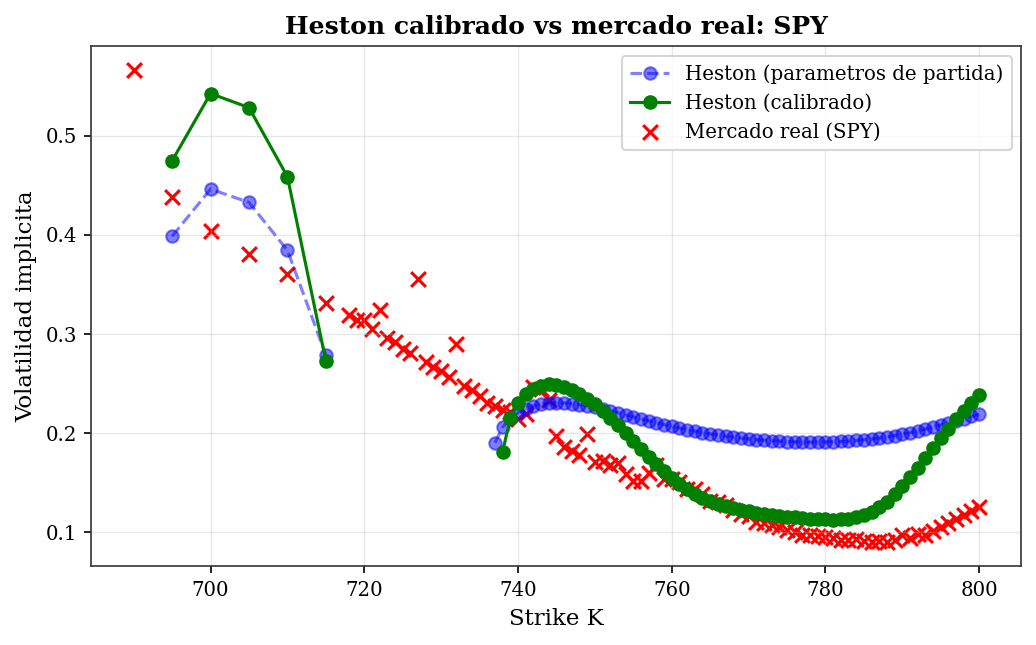

Precio inicial S0 772.72998046875


In [ ]:
precios_mercado_real = calls["mid"].values   # precios reales, no hace falta invertir vol->precio: ya los tenemos

def residuos(x):
    v0, kappa, theta, xi, rho = x
    precios_modelo = np.array([
        heston_call_price(S0_real, K, T_real, kappa=kappa, theta=theta, xi=xi, rho=rho, v0=v0, r=r)
        for K in strikes
    ])
    return precios_modelo - precios_mercado_real


# punto de partida: los mismos parametros iniciales ya usados en el resto del notebook.
x0 = [v0, kappa, theta, xi, rho]
bounds = ([1e-4, 1e-4, 1e-4, 1e-4, -0.999], [1.0, 10.0, 1.0, 3.0, 0.999])

resultado = optimize.least_squares(residuos, x0, bounds=bounds)
v0_cal, kappa_cal, theta_cal, xi_cal, rho_cal = resultado.x

print("Parametro      Partida      Calibrado")
print(f"v0             {v0:.4f}       {v0_cal:.4f}")
print(f"kappa          {kappa:.4f}       {kappa_cal:.4f}")
print(f"theta          {theta:.4f}       {theta_cal:.4f}")
print(f"xi             {xi:.4f}       {xi_cal:.4f}")
print(f"rho            {rho:.4f}      {rho_cal:.4f}")
print(f"\n Error cuadratico medio final (precios): {np.mean(resultado.fun**2):.6f}")



###########################
###########################
########################### Represetaciones: curva calibrada vs mercado real vs Heston sin calibrar
vols_heston_cal = np.array([
    implied_vol(heston_call_price(S0_real, K, T_real, kappa_cal, theta_cal, xi_cal, rho_cal, v0_cal, r),
                S0_real, K, T_real, r)
    for K in strikes
])

plt.plot(strikes, vols_heston, 'b--', marker='o', alpha=0.5, label='Heston (parametros de partida)')
plt.plot(strikes, vols_heston_cal, 'g-', marker='o', label='Heston (calibrado)')
plt.scatter(strikes, vols, color='red', marker='x', s=50, label='Mercado real (SPY)')
plt.xlabel('Strike K')
plt.ylabel('Volatilidad implicita')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Heston calibrado vs mercado real: SPY')
#plt.savefig('heston_calibrado_mercado_spy.pdf', bbox_inches='tight', dpi=220)   # celda 17
plt.show()

print("Precio inicial S0", S0_real)

**Nota sobre el resultado:** la calibracion mejora sustancialmente el ajuste en la zona de strikes entre 760 y 780 precisamente los mas cercanos a $S_0$ (ligeramente ITM y OTM), donde hay mas liquidez y por tanto precios mas fiables. El ajuste es peor en los extremos (strikes muy alejados de $S_0$), donde las opciones son mas iliquidas y los precios observados menos representativos del "verdadero" precio de mercado.